In [12]:
import pandas as pd
import ast
import re
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from pathlib import Path

DATA_PATH = Path("data_clean/07_final_case_dataset.xlsx")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

df = pd.read_excel(DATA_PATH)

def safe_list(x):
    if isinstance(x, list):
        return x
    try:
        return ast.literal_eval(x)
    except:
        return []

df["target_companies_clean"] = df["target_companies_clean"].apply(safe_list)
df["claim_types"] = df["claim_types"].apply(safe_list)

if "year" not in df.columns:
    df["year"] = df["title"].astype(str).str.extract(r"(20\d{2})")

df["year"] = pd.to_numeric(df["year"], errors="coerce")

df.shape

(73, 42)

In [13]:
df.head()

,title,publication_location,publication,publication_type,court,citation,attorney,cite,concur,concur_by,...,has_clean_company,keep_after_company_cleaning,auto_relevant,auto_score,auto_reason,review_priority,manual_relevant,manual_notes,final_relevant,year
0,"Barkley & Assocs., Inc. v. Quizlet, Inc., 2025...",U.S. Federal,9th Circuit - US District Court Cases,Cases,NaN,NaN,"For Quizlet Inc. , a Delaware corporation regi...",NaN,NaN,NaN,...,True,True,1,10,core_ai_company; copyright_signal; training_da...,1,NaN,NaN,1,2025.0
1,"In re Google Generative AI Copyright Litig., 2...",U.S. Federal,9th Circuit - US District Court Cases,Cases,NaN,NaN,"For Jill Leovy, Plaintiff: Lesley Elizabeth We...",NaN,NaN,NaN,...,True,True,1,10,core_ai_company; copyright_signal; training_da...,1,NaN,NaN,1,2025.0
2,"N.Y. Times Co. v. Microsoft Corp., 757 F. Supp...",U.S. Federal,2nd Circuit - US District Court Cases,Cases,NaN,NaN,"For The New York Times Company , Plaintiff: Al...",NaN,NaN,NaN,...,True,True,1,10,core_ai_company; copyright_signal; training_da...,1,NaN,NaN,1,NaN
3,"In re Openai, Inc., Copyright Infringement Lit...",U.S. Federal,2nd Circuit - US District Court Cases,Cases,NaN,NaN,"For OpenAI, Inc. Copyright Infringement Litiga...",NaN,NaN,NaN,...,True,True,1,7,core_ai_company; copyright_signal; training_da...,1,NaN,NaN,1,2025.0
4,Thomson Reuters Enter. Ctr. GmbH v. Ross Intel...,U.S. Federal,3rd Circuit - US District Court Cases,Cases,NaN,NaN,"Jack B. Blumenfeld , Michael J. Flynn , MORRIS...",NaN,NaN,NaN,...,True,True,1,10,core_ai_company; copyright_signal; training_da...,1,NaN,NaN,1,NaN


In [16]:
CORE_AI_COMPANIES = {
    "OpenAI", "Microsoft", "Google", "Meta", "Anthropic",
    "Stability AI", "Midjourney", "Suno", "Udio",
    "Perplexity", "Cohere", "Nvidia", "xAI",
    "ElevenLabs", "ByteDance", "Bloomberg",
    "Ross Intelligence", "UMG"
}

# Flatten all detected companies
all_company_rows = []

for _, row in df.iterrows():
    for company in row["target_companies_clean"]:
        all_company_rows.append(company)

all_company_counts = pd.Series(all_company_rows).value_counts()

# Frequent small companies: detected at least twice
FREQUENT_COMPANIES = set(all_company_counts[all_company_counts >= 3].index)

# Plot companies = core companies + frequent small companies
PLOT_COMPANIES = CORE_AI_COMPANIES | FREQUENT_COMPANIES

def keep_plot_companies(companies):
    return sorted([c for c in companies if c in PLOT_COMPANIES])

df["plot_companies"] = df["target_companies_clean"].apply(keep_plot_companies)

df_plot = df[df["plot_companies"].apply(len) > 0].copy()

print("Total cases:", len(df))
print("Cases with plot companies:", len(df_plot))
print("All detected companies:", len(all_company_counts))
print("Plot companies:", len(PLOT_COMPANIES))

all_company_counts.head(30)

Total cases: 73
Cases with plot companies: 72
All detected companies: 454
Plot companies: 32


OpenAI                           43
Ross Intelligence                38
Google                           25
Microsoft                        24
Meta                             18
Apple                            10
Oracle                           10
Stability AI                      6
xAI                               6
Anthropic                         5
Fourth Est. Pub. Benefit Corp     4
Tesla                             4
OpenAI LLC                        4
Bell Atlantic Corp                4
ByteDance                         3
Amazon                            3
Perplexity                        3
AMF Inc                           3
News Corp                         3
OPENAI GLOBAL LLC                 3
Zenith Radio Corp                 3
TransUnion LLC                    3
Bloomberg                         3
Exxon Corp                        3
Google Generative AI              3
Three Boys Music Corp             2
Network Automation Inc            2
S&N Global Supply Inc       

In [17]:
plot_company_rows = []

for _, row in df_plot.iterrows():
    for company in row["plot_companies"]:
        plot_company_rows.append(company)

plot_company_counts = pd.Series(plot_company_rows).value_counts()

plot_company_counts

OpenAI                           43
Ross Intelligence                38
Google                           25
Microsoft                        24
Meta                             18
Oracle                           10
Apple                            10
xAI                               6
Stability AI                      6
Anthropic                         5
OpenAI LLC                        4
Tesla                             4
Bell Atlantic Corp                4
Fourth Est. Pub. Benefit Corp     4
ByteDance                         3
Perplexity                        3
AMF Inc                           3
News Corp                         3
Exxon Corp                        3
Bloomberg                         3
Amazon                            3
TransUnion LLC                    3
OPENAI GLOBAL LLC                 3
Google Generative AI              3
Zenith Radio Corp                 3
Midjourney                        1
Suno                              1
Nvidia                      

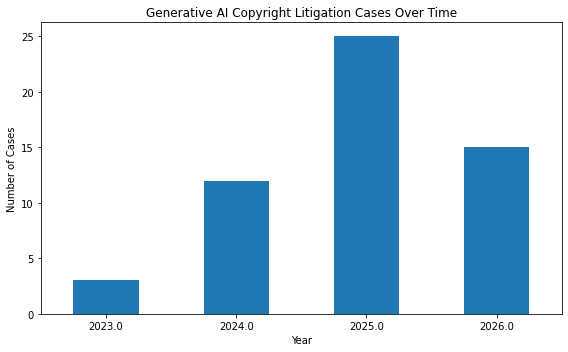

In [18]:
year_counts = (
    df.dropna(subset=["year"])
      .groupby("year")
      .size()
      .sort_index()
)

plt.figure(figsize=(8, 5))
year_counts.plot(kind="bar")
plt.title("Generative AI Copyright Litigation Cases Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Cases")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_cases_over_time.png", dpi=300)
plt.show()

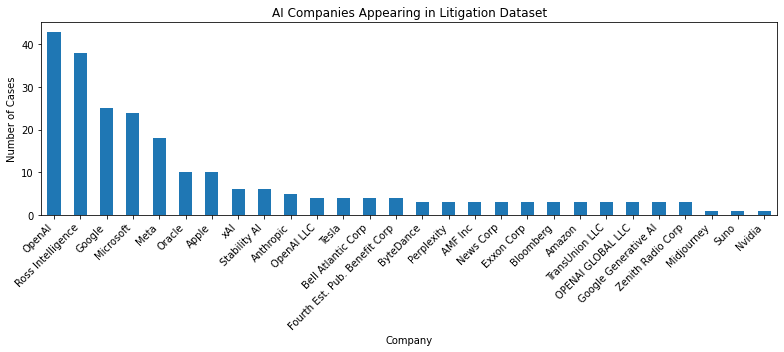

In [19]:
plt.figure(figsize=(11, 5))
plot_company_counts.plot(kind="bar")
plt.title("AI Companies Appearing in Litigation Dataset")
plt.xlabel("Company")
plt.ylabel("Number of Cases")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_core_plus_frequent_company_counts.png", dpi=300)
plt.show()

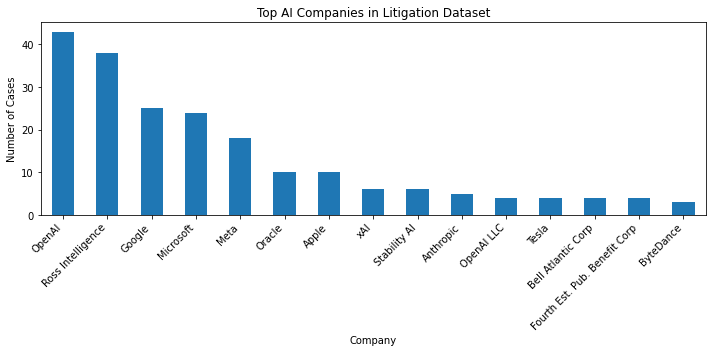

In [20]:
top_company_counts = plot_company_counts.head(15)

plt.figure(figsize=(10, 5))
top_company_counts.plot(kind="bar")
plt.title("Top AI Companies in Litigation Dataset")
plt.xlabel("Company")
plt.ylabel("Number of Cases")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig3_top15_company_counts.png", dpi=300)
plt.show()

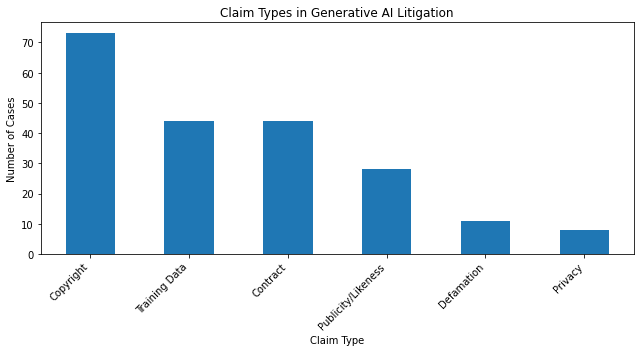

Copyright             73
Training Data         44
Contract              44
Publicity/Likeness    28
Defamation            11
Privacy                8
Name: count, dtype: int64

In [21]:
claim_rows = []

for _, row in df.iterrows():
    for claim in row["claim_types"]:
        claim_rows.append(claim)

claim_counts = pd.Series(claim_rows).value_counts()

plt.figure(figsize=(9, 5))
claim_counts.plot(kind="bar")
plt.title("Claim Types in Generative AI Litigation")
plt.xlabel("Claim Type")
plt.ylabel("Number of Cases")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig4_claim_type_counts.png", dpi=300)
plt.show()

claim_counts

Text(0, 0.5, 'Company')

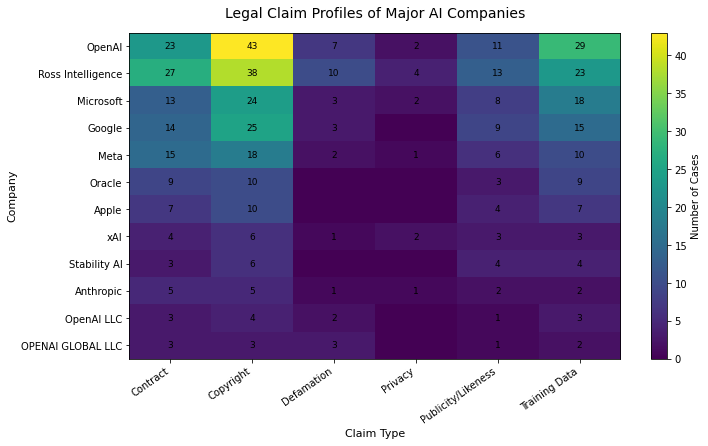

In [34]:
# Better Figure: Company × Claim Type Heatmap

# 只保留前 12 个公司，避免太挤
top_n = 12
top_companies = heat_table.sum(axis=1).sort_values(ascending=False).head(top_n).index
heat_table_top = heat_table.loc[top_companies]

plt.figure(figsize=(11, 6))

im = plt.imshow(heat_table_top, aspect="auto")

plt.xticks(
    range(len(heat_table_top.columns)),
    heat_table_top.columns,
    rotation=35,
    ha="right",
    fontsize=10
)

plt.yticks(
    range(len(heat_table_top.index)),
    heat_table_top.index,
    fontsize=10
)

plt.colorbar(im, label="Number of Cases")

# 在格子里加数字
for i in range(len(heat_table_top.index)):
    for j in range(len(heat_table_top.columns)):
        value = heat_table_top.iloc[i, j]
        if value > 0:
            plt.text(
                j,
                i,
                int(value),
                ha="center",
                va="center",
                fontsize=9
            )

plt.title("Legal Claim Profiles of Major AI Companies", fontsize=14, pad=15)
plt.xlabel("Claim Type", fontsize=11)
plt.ylabel("Company", fontsize=11)

# plt.tight_layout()
# plt.savefig(FIG_DIR / "fig5_company_claim_heatmap_better.png", dpi=300)
# plt.show()

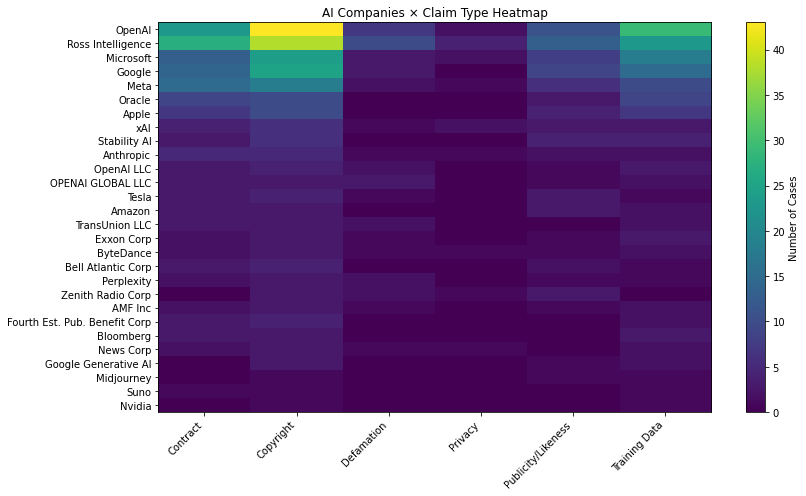

In [22]:
heat_rows = []

for _, row in df_plot.iterrows():
    for company in row["plot_companies"]:
        for claim in row["claim_types"]:
            heat_rows.append({
                "company": company,
                "claim": claim
            })

heat_df = pd.DataFrame(heat_rows)

heat_table = pd.crosstab(heat_df["company"], heat_df["claim"])

# order rows by total count
heat_table = heat_table.loc[heat_table.sum(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(12, 7))
plt.imshow(heat_table, aspect="auto")
plt.xticks(range(len(heat_table.columns)), heat_table.columns, rotation=45, ha="right")
plt.yticks(range(len(heat_table.index)), heat_table.index)
plt.colorbar(label="Number of Cases")
plt.title("AI Companies × Claim Type Heatmap")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig5_company_claim_heatmap.png", dpi=300)
plt.show()

In [23]:
link_df = heat_df.value_counts(["company", "claim"]).reset_index(name="value")

labels = list(pd.unique(link_df[["company", "claim"]].values.ravel()))
label_to_id = {label: i for i, label in enumerate(labels)}

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=18,
        label=labels
    ),
    link=dict(
        source=link_df["company"].map(label_to_id),
        target=link_df["claim"].map(label_to_id),
        value=link_df["value"]
    )
)])

fig.update_layout(
    title_text="AI Litigation Flow: Companies → Claim Types",
    font_size=12
)

fig.write_html(FIG_DIR / "fig6_company_claim_sankey.html")
fig.show()

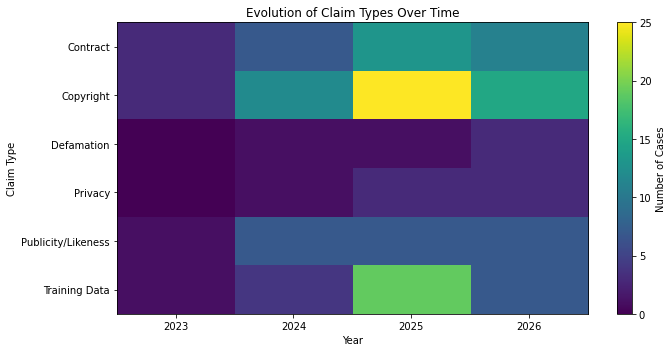

In [24]:
timeline_rows = []

for _, row in df.iterrows():
    if pd.isna(row["year"]):
        continue

    for claim in row["claim_types"]:
        timeline_rows.append({
            "year": int(row["year"]),
            "claim": claim
        })

timeline_df = pd.DataFrame(timeline_rows)

timeline_table = pd.crosstab(timeline_df["claim"], timeline_df["year"])

plt.figure(figsize=(10, 5))
plt.imshow(timeline_table, aspect="auto")
plt.xticks(range(len(timeline_table.columns)), timeline_table.columns)
plt.yticks(range(len(timeline_table.index)), timeline_table.index)
plt.colorbar(label="Number of Cases")
plt.title("Evolution of Claim Types Over Time")
plt.xlabel("Year")
plt.ylabel("Claim Type")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig7_claim_timeline_heatmap.png", dpi=300)
plt.show()

In [26]:
def extract_plaintiff(title):
    title = str(title)

    # common case names: Plaintiff v. Defendant
    if " v. " in title:
        return title.split(" v. ")[0].strip()

    if " vs. " in title:
        return title.split(" vs. ")[0].strip()

    if title.lower().startswith("in re"):
        return "In re / MDL"

    return title[:60]

In [27]:
CORE_AI_COMPANIES = {
    "OpenAI", "Microsoft", "Google", "Meta", "Anthropic",
    "Stability AI", "Midjourney", "Suno", "Udio",
    "Perplexity", "Cohere", "Nvidia", "xAI",
    "ElevenLabs", "ByteDance", "Bloomberg",
    "Ross Intelligence", "UMG"
}

def keep_core_companies(companies):
    return [c for c in companies if c in CORE_AI_COMPANIES]

df["plaintiff"] = df["title"].apply(extract_plaintiff)
df["core_defendants"] = df["target_companies_clean"].apply(keep_core_companies)

df_sue = df[df["core_defendants"].apply(len) > 0].copy()

In [32]:
edges = []

for _, row in df_sue.iterrows():
    plaintiff = row["plaintiff"]

    for defendant in row["core_defendants"]:

        # remove self-loop
        if plaintiff.lower().strip() == defendant.lower().strip():
            continue

        # fuzzy remove: OpenAI Inc. vs OpenAI
        if defendant.lower() in plaintiff.lower():
            continue

        edges.append({
            "plaintiff": plaintiff,
            "defendant": defendant
        })

edge_df = pd.DataFrame(edges)

edge_counts = (
    edge_df
    .value_counts(["plaintiff", "defendant"])
    .reset_index(name="value")
)

In [33]:
labels = list(pd.unique(edge_counts[["plaintiff", "defendant"]].values.ravel()))
label_to_id = {label: i for i, label in enumerate(labels)}

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=18,
        thickness=16,
        label=labels
    ),
    link=dict(
        source=edge_counts["plaintiff"].map(label_to_id),
        target=edge_counts["defendant"].map(label_to_id),
        value=edge_counts["value"]
    )
)])

fig.update_layout(
    title_text="Who's Suing Whom? Plaintiffs → Core AI Defendants",
    font_size=12,
    width=1000,
    height=800
)

fig.write_html(FIG_DIR / "fig_plaintiff_core_ai_defendant_sankey.html")
fig.show()

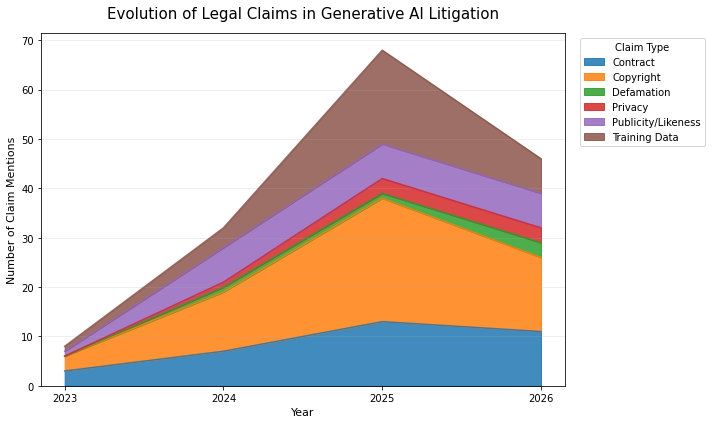

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Build long-format claim data
# -----------------------------
timeline_rows = []

for _, row in df.iterrows():
    if pd.isna(row["year"]):
        continue

    year = int(row["year"])

    for claim in row["claim_types"]:
        timeline_rows.append({
            "year": year,
            "claim": claim
        })

timeline_df = pd.DataFrame(timeline_rows)

# -----------------------------
# Aggregate by year × claim
# -----------------------------
claim_year = (
    timeline_df
    .groupby(["year", "claim"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# Optional fixed order
claim_order = [
    "Contract",
    "Copyright",
    "Defamation",
    "Privacy",
    "Publicity/Likeness",
    "Training Data"
]

claim_year = claim_year[[c for c in claim_order if c in claim_year.columns]]

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))

claim_year.plot(
    kind="area",
    stacked=True,
    alpha=0.85,
    ax=ax
)

# Clean integer year axis
years = claim_year.index.tolist()
ax.set_xticks(years)
ax.set_xticklabels([str(y) for y in years])

# Labels and style
ax.set_title(
    "Evolution of Legal Claims in Generative AI Litigation",
    fontsize=15,
    pad=15
)

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Number of Claim Mentions", fontsize=11)

ax.grid(axis="y", alpha=0.25)

ax.legend(
    title="Claim Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "advanced_claim_composition_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

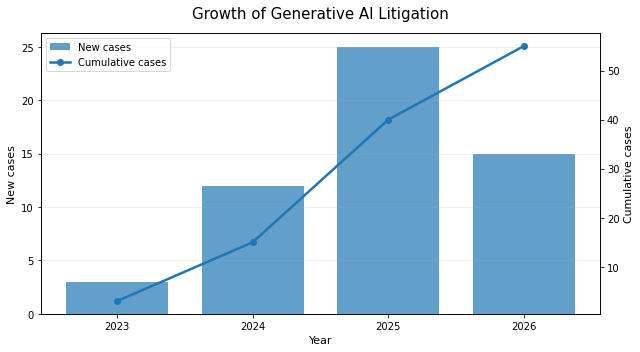

In [40]:
import matplotlib.pyplot as plt

# ---------------------------------
# Cases per year
# ---------------------------------
case_year = (
    df.dropna(subset=["year"])
    .groupby("year")
    .size()
    .sort_index()
)

case_year.index = case_year.index.astype(int)

# Cumulative
cumulative = case_year.cumsum()

# ---------------------------------
# Plot
# ---------------------------------
fig, ax1 = plt.subplots(figsize=(9, 5))

# Bars = new cases
bars = ax1.bar(
    case_year.index,
    case_year.values,
    alpha=0.70,
    width=0.75,
    label="New cases"
)

ax1.set_xlabel("Year", fontsize=11)
ax1.set_ylabel("New cases", fontsize=11)

# Clean integer x-axis
years = case_year.index.tolist()
ax1.set_xticks(years)
ax1.set_xticklabels([str(y) for y in years])

# Secondary axis = cumulative
ax2 = ax1.twinx()

line = ax2.plot(
    cumulative.index,
    cumulative.values,
    marker="o",
    linewidth=2.5,
    label="Cumulative cases"
)

ax2.set_ylabel("Cumulative cases", fontsize=11)

# Title
plt.title(
    "Growth of Generative AI Litigation",
    fontsize=15,
    pad=15
)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)

# Grid
ax1.grid(axis="y", alpha=0.25)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "advanced_litigation_growth_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

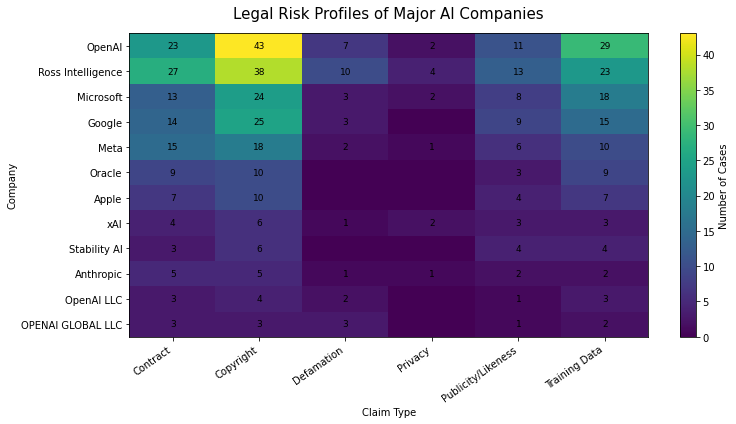

In [37]:
# Better heatmap: only top companies, with numbers

top_n = 12

top_companies = (
    heat_table
    .sum(axis=1)
    .sort_values(ascending=False)
    .head(top_n)
    .index
)

heat_table_top = heat_table.loc[top_companies]

plt.figure(figsize=(11, 6))
im = plt.imshow(heat_table_top, aspect="auto")

plt.xticks(
    range(len(heat_table_top.columns)),
    heat_table_top.columns,
    rotation=35,
    ha="right",
    fontsize=10
)

plt.yticks(
    range(len(heat_table_top.index)),
    heat_table_top.index,
    fontsize=10
)

plt.colorbar(im, label="Number of Cases")

for i in range(len(heat_table_top.index)):
    for j in range(len(heat_table_top.columns)):
        value = heat_table_top.iloc[i, j]
        if value > 0:
            plt.text(j, i, int(value), ha="center", va="center", fontsize=9)

plt.title("Legal Risk Profiles of Major AI Companies", fontsize=15, pad=15)
plt.xlabel("Claim Type")
plt.ylabel("Company")
plt.tight_layout()
plt.savefig(FIG_DIR / "advanced_company_legal_risk_heatmap.png", dpi=300)
plt.show()

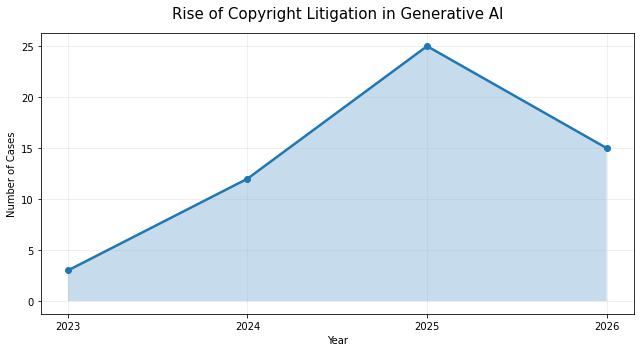

In [41]:
# Figure: Copyright litigation over time

copyright_df = df[
    df["claim_types"].apply(lambda x: "Copyright" in x)
].copy()

copyright_year = (
    copyright_df
    .groupby("year")
    .size()
    .sort_index()
)

plt.figure(figsize=(9,5))

plt.plot(
    copyright_year.index,
    copyright_year.values,
    marker="o",
    linewidth=2.5
)

plt.fill_between(
    copyright_year.index,
    copyright_year.values,
    alpha=0.25
)

plt.xticks(copyright_year.index)
plt.title("Rise of Copyright Litigation in Generative AI", fontsize=15, pad=15)
plt.xlabel("Year")
plt.ylabel("Number of Cases")
plt.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(FIG_DIR / "copyright_cases_over_time.png", dpi=300)
plt.show()

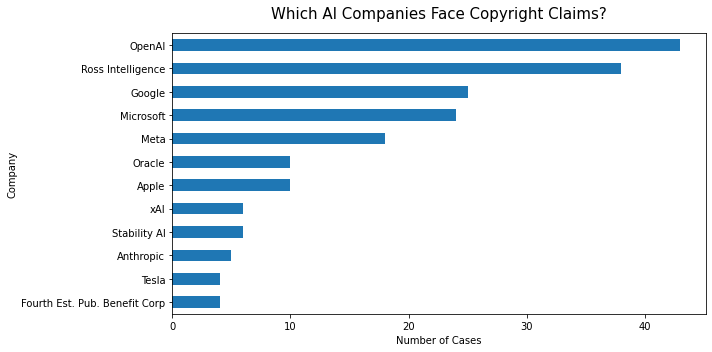

In [42]:
# Figure: AI companies in copyright cases

rows = []

for _, row in copyright_df.iterrows():
    for company in row["target_companies_clean"]:
        rows.append(company)

company_counts = pd.Series(rows).value_counts().head(12)

plt.figure(figsize=(10,5))

company_counts.sort_values().plot(kind="barh")

plt.title("Which AI Companies Face Copyright Claims?", fontsize=15, pad=15)
plt.xlabel("Number of Cases")
plt.ylabel("Company")

plt.tight_layout()
plt.savefig(FIG_DIR / "copyright_company_counts.png", dpi=300)
plt.show()

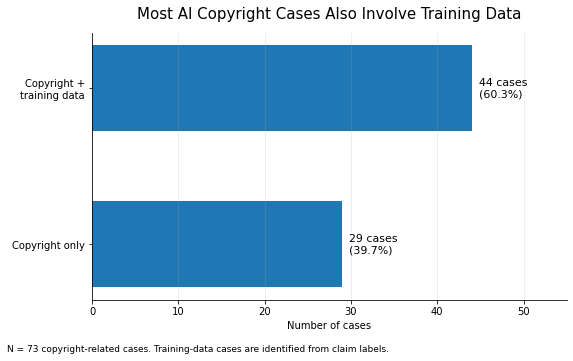

In [45]:
# Advanced Figure: Copyright vs Training Data Overlap

import matplotlib.pyplot as plt
import pandas as pd

copyright_df = df[
    df["claim_types"].apply(lambda x: "Copyright" in x)
].copy()

copyright_df["has_training"] = copyright_df["claim_types"].apply(
    lambda x: "Training Data" in x
)

counts = pd.Series({
    "Copyright only": (~copyright_df["has_training"]).sum(),
    "Copyright +\ntraining data": copyright_df["has_training"].sum()
})

total = counts.sum()
percentages = counts / total * 100

fig, ax = plt.subplots(figsize=(8, 4.8))

bars = ax.barh(
    counts.index,
    counts.values,
    height=0.55
)

for i, (label, value) in enumerate(counts.items()):
    pct = percentages[label]
    ax.text(
        value + 0.8,
        i,
        f"{int(value)} cases\n({pct:.1f}%)",
        va="center",
        fontsize=11
    )

ax.set_title(
    "Most AI Copyright Cases Also Involve Training Data",
    fontsize=15,
    pad=14
)

ax.set_xlabel("Number of cases")
ax.set_ylabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.25)

ax.set_xlim(0, counts.max() * 1.25)

caption = (
    f"N = {total} copyright-related cases. "
    "Training-data cases are identified from claim labels."
)

plt.figtext(
    0.01,
    -0.03,
    caption,
    ha="left",
    fontsize=9
)

plt.tight_layout()
plt.savefig(
    FIG_DIR / "copyright_training_overlap_advanced.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [44]:
# Copyright sankey dataset

edges = []

for _, row in copyright_df.iterrows():
    plaintiff = row["plaintiff"]

    for defendant in row["core_defendants"]:
        if plaintiff.lower() in defendant.lower():
            continue

        edges.append({
            "source": plaintiff,
            "target": defendant
        })

edge_df = pd.DataFrame(edges)
edge_counts = edge_df.value_counts(["source","target"]).reset_index(name="value")

In [46]:
# Copyright-only Plaintiff → Core AI Defendant Sankey

copyright_sankey_df = df[
    df["claim_types"].apply(lambda x: "Copyright" in x)
].copy()

edges = []

for _, row in copyright_sankey_df.iterrows():
    plaintiff = row.get("plaintiff", "")

    if not plaintiff or pd.isna(plaintiff):
        plaintiff = str(row.get("title", "")).split(" v. ")[0]

    for defendant in row.get("core_defendants", row.get("plot_companies", [])):
        if not defendant:
            continue

        if defendant.lower() in str(plaintiff).lower():
            continue

        edges.append({
            "source": plaintiff,
            "target": defendant
        })

edge_df = pd.DataFrame(edges)

edge_counts = (
    edge_df
    .value_counts(["source", "target"])
    .reset_index(name="value")
    .sort_values("value", ascending=False)
    .head(25)
)

labels = list(pd.unique(edge_counts[["source", "target"]].values.ravel()))
label_to_id = {label: i for i, label in enumerate(labels)}

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=18,
        thickness=16,
        label=labels
    ),
    link=dict(
        source=edge_counts["source"].map(label_to_id),
        target=edge_counts["target"].map(label_to_id),
        value=edge_counts["value"]
    )
)])

fig.update_layout(
    title_text="Copyright Litigation: Plaintiffs → Core AI Defendants",
    font_size=12,
    width=1000,
    height=750
)

fig.write_html(FIG_DIR / "copyright_plaintiff_defendant_sankey.html")
fig.show()